In [1]:
# Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#  ML Related 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import MinMaxScaler, StandardScaler # Feature Scaling
from sklearn import metrics # R^2, MSE, RMSE etc...

In [2]:
df=pd.read_csv(r"C:\Users\acer\OneDrive\Pictures\ML\train.csv")

In [3]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


### EDA-exploratory data analysis
### univariate - numerical ,Categorical
### Bivariate - Cat-Cat, num -Cat, Num - Num

# UNIVARIATE

### SEPERATE CAT & NUM COLUMNS

### categorical variables(cat)

In [4]:
df.dtypes[df.dtypes=="object"].index  #categorical variables(cat)

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

In [6]:
df.select_dtypes(include=["object"]).columns

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

### numerical variables(num)

In [5]:
df.dtypes[df.dtypes!="object"].index  #numerical variables(num)

Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score'],
      dtype='object')

In [28]:
df.select_dtypes(exclude=["object"]).columns

Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score'],
      dtype='object')

### assigned categorical variables to cat_columns

In [6]:
cat_columns=['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty']

### EDA (Study each variable at a time)

In [33]:
df["gender"].unique()

array(['female', 'other', 'male'], dtype=object)

In [42]:
df["gender"].value_counts()
#counts how often each unique value appears in that column.

gender
other     211097
male      210593
female    208310
Name: count, dtype: int64

In [52]:
df["gender"].value_counts(normalize= True , dropna=False) 
#percentage- normalize=True, #NaN/ missing values are included--dropna=False

gender
other     0.335075
male      0.334275
female    0.330651
Name: proportion, dtype: float64

In [38]:
df["course"].unique()

array(['b.sc', 'diploma', 'bca', 'b.com', 'ba', 'bba', 'b.tech'],
      dtype=object)

In [40]:
df["course"].value_counts()

course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64

In [41]:
df["course"].value_counts(normalize=True, dropna=False)  
#percentage- normalize=True, #NaN /missing values are included--dropna=False

course
b.tech     0.208311
b.sc       0.177070
b.com      0.176083
bca        0.140827
bba        0.120070
ba         0.098395
diploma    0.079244
Name: proportion, dtype: float64

In [43]:
df["internet_access"].unique()

array(['no', 'yes'], dtype=object)

In [48]:
df["internet_access"].value_counts()

internet_access
yes    579423
no      50577
Name: count, dtype: int64

In [49]:
df["internet_access"].value_counts(normalize=True , dropna= False)

internet_access
yes    0.919719
no     0.080281
Name: proportion, dtype: float64

In [44]:
df["sleep_quality"].unique()

array(['average', 'poor', 'good'], dtype=object)

In [50]:
df["sleep_quality"].value_counts()

sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64

In [51]:
df["sleep_quality"].value_counts(normalize=True, dropna=False)

sleep_quality
poor       0.339167
good       0.338237
average    0.322597
Name: proportion, dtype: float64

In [45]:
df["study_method"].unique()

array(['online videos', 'self-study', 'coaching', 'group study', 'mixed'],
      dtype=object)

In [54]:
df["study_method"].value_counts()

study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64

In [53]:
df["study_method"].value_counts(normalize=True, dropna=False)

study_method
coaching         0.209043
self-study       0.208144
mixed            0.195375
group study      0.195252
online videos    0.192186
Name: proportion, dtype: float64

In [46]:
df["facility_rating"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [56]:
df["facility_rating"].value_counts()

facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64

In [55]:
df["facility_rating"].value_counts(normalize=True, dropna=False)

facility_rating
medium    0.339813
low       0.337108
high      0.323079
Name: proportion, dtype: float64

In [47]:
df["exam_difficulty"].unique()

array(['easy', 'moderate', 'hard'], dtype=object)

In [57]:
df["exam_difficulty"].value_counts()

exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64

In [58]:
df["exam_difficulty"].value_counts(normalize=True, dropna=False)

exam_difficulty
moderate    0.561876
easy        0.280222
hard        0.157902
Name: proportion, dtype: float64

### Assigned Numerical variables to num_columns

In [7]:
num_columns=['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score']

### EDA (Study each variable at a time)

In [61]:
df[num_columns].min()

id                   0.000
age                 17.000
study_hours          0.080
class_attendance    40.600
sleep_hours          4.100
exam_score          19.599
dtype: float64

In [62]:
df[num_columns].max()

id                  629999.00
age                     24.00
study_hours              7.91
class_attendance        99.40
sleep_hours              9.90
exam_score             100.00
dtype: float64

In [63]:
df[num_columns].std()

id                  181865.479132
age                      2.260238
study_hours              2.359880
class_attendance        17.430098
sleep_hours              1.744811
exam_score              18.916884
dtype: float64

In [64]:
df[num_columns].mean()

id                  314999.500000
age                     20.545821
study_hours              4.002337
class_attendance        71.987261
sleep_hours              7.072758
exam_score              62.506672
dtype: float64

In [66]:
df[num_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.000,157499.75,314999.5,472499.25,629999.00
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [69]:
df.info()  #to check missing #In this no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [87]:
df[num_columns].describe(percentiles=[.1,.2,.3,.98,.99]).T 
# to check outliers , #NO OUTLIERS IN THIS

,count,mean,std,min,10%,20%,30%,50%,98%,99%,max
id,630000.0,314999.500000,181865.479132,0.000,62999.90,125999.80,188999.70,314999.5,617399.02,623699.01,629999.00
age,630000.0,20.545821,2.260238,17.000,17.00,18.00,19.00,21.0,24.00,24.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,0.75,1.56,2.37,4.0,7.91,7.91,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,47.60,53.50,60.40,72.6,99.40,99.40,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,4.60,5.30,5.90,7.1,9.90,9.90,9.90
exam_score,630000.0,62.506672,18.916884,19.599,37.40,45.50,51.80,62.6,100.00,100.00,100.00


## BIVARIATE

### num to num

In [75]:
df[num_columns].corr() # corelation  #num to num

,id,age,study_hours,class_attendance,sleep_hours,exam_score
id,1.000000,-0.000581,0.000346,0.000677,0.001416,0.000372
age,-0.000581,1.000000,0.007545,0.005628,0.005864,0.010472
study_hours,0.000346,0.007545,1.000000,0.087617,0.042491,0.762267
class_attendance,0.000677,0.005628,0.087617,1.000000,0.029263,0.360954
sleep_hours,0.001416,0.005864,0.042491,0.029263,1.000000,0.167410
exam_score,0.000372,0.010472,0.762267,0.360954,0.167410,1.000000


In [8]:
df1=df.sample(5000)

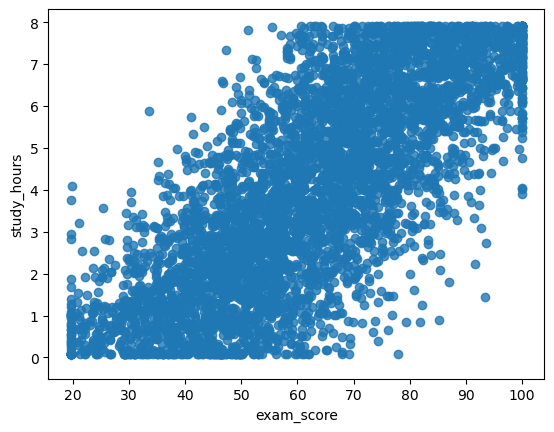

In [9]:
sns.regplot(data=df1, x="exam_score", y="study_hours")
plt.show()
#no variable has corr greater than 0.5 with exam score but study hours has 0.76 correlation with exam score

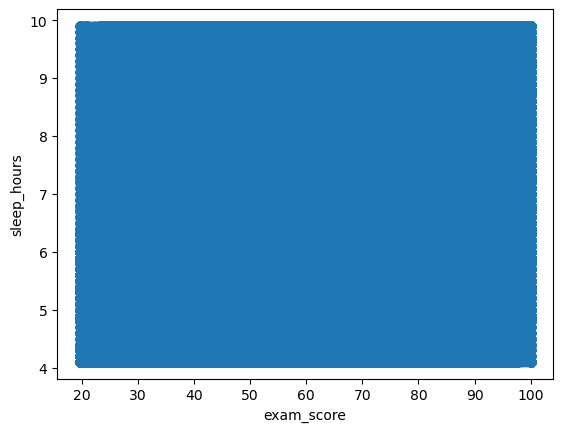

In [69]:
sns.regplot(data=df1, x="exam_score", y="sleep_hours")
plt.show()

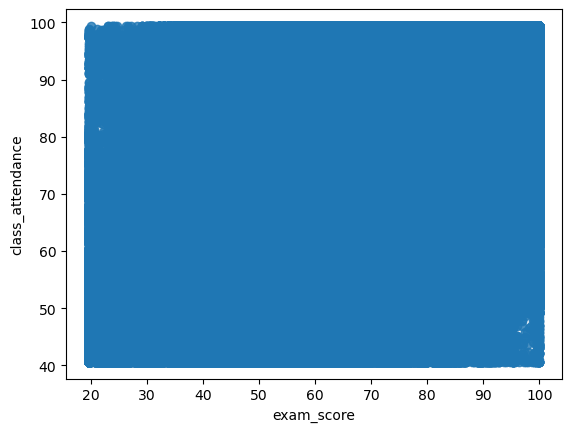

In [70]:
sns.regplot(data=df1, x="exam_score", y="class_attendance")
plt.show()

### num to cat

In [10]:
df.groupby("gender").agg({"exam_score":["mean", "min", "max", "std", "count"]})  #num to cat

exam_score                                  
             mean     min    max        std   count
gender                                             
female  62.563220  19.599  100.0  18.891115  208310
male    62.175561  19.599  100.0  18.765553  210593
other   62.781191  19.599  100.0  19.087020  211097

In [77]:
df.groupby("course").agg({"exam_score":["mean", "min", "max", "std", "count"]})

exam_score                                  
              mean     min    max        std   count
course                                              
b.com    62.537726  19.599  100.0  18.404936  110932
b.sc     62.295491  19.599  100.0  19.297236  111554
b.tech   62.519707  19.599  100.0  18.862381  131236
ba       61.886931  19.599  100.0  18.765944   61989
bba      63.232038  19.599  100.0  19.159462   75644
bca      62.586227  19.599  100.0  18.921838   88721
diploma  62.404354  19.599  100.0  19.094986   49924

In [78]:
df.groupby("internet_access").agg({"exam_score":["mean", "min", "max", "std", "count"]})

exam_score                                  
                      mean     min    max        std   count
internet_access                                             
no               62.478038  19.599  100.0  19.277820   50577
yes              62.509172  19.599  100.0  18.885066  579423

In [79]:
df.groupby("sleep_quality").agg({"exam_score":["mean", "min", "max", "std", "count"]})

exam_score                                  
                    mean     min    max        std   count
sleep_quality                                             
average        62.662000  19.599  100.0  18.601369  203236
good           67.884885  19.599  100.0  18.117352  213089
poor           56.995470  19.599  100.0  18.422746  213675

In [80]:
df.groupby("study_method").agg({"exam_score":["mean", "min", "max", "std", "count"]})

exam_score                                  
                    mean     min    max        std   count
study_method                                              
coaching       69.266665  19.599  100.0  18.446089  131697
group study    60.531838  19.599  100.0  18.219917  123009
mixed          65.101735  19.599  100.0  18.218035  123086
online videos  59.727607  19.599  100.0  18.729355  121077
self-study     57.700155  19.599  100.0  18.562730  131131

In [81]:
df.groupby("facility_rating").agg({"exam_score":["mean", "min", "max", "std", "count"]})

exam_score                                  
                      mean     min    max        std   count
facility_rating                                             
high             66.707126  19.599  100.0  18.525910  203540
low              57.954546  19.599  100.0  18.563344  212378
medium           63.028954  19.599  100.0  18.636271  214082

In [82]:
df.groupby("exam_difficulty").agg({"exam_score":["mean", "min", "max", "std", "count"]})

exam_score                                  
                      mean     min    max        std   count
exam_difficulty                                             
easy             62.214401  19.599  100.0  18.708772  176540
hard             62.671693  19.599  100.0  19.136236   99478
moderate         62.606060  19.599  100.0  18.956526  353982

## PREPROCESSING

### MISSING

In [88]:
df.isnull().sum()  #no missing

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

### OUTLIERS

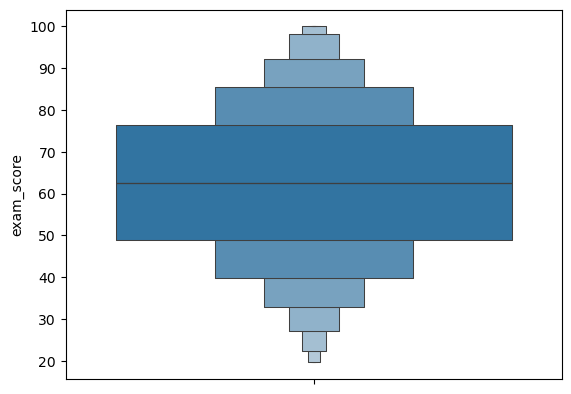

In [86]:
sns.boxenplot(data=df, y="exam_score")
plt.show()
#NO OUTLIERS

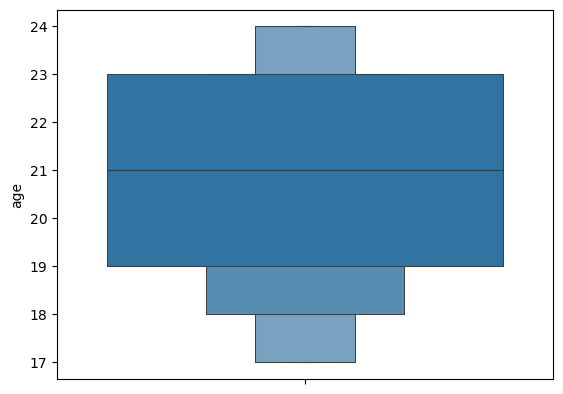

In [89]:
sns.boxenplot(data=df, y="age")
plt.show()

In [90]:
df.duplicated().sum() # no duplicated

np.int64(0)

#### encoding  categorical to number

In [92]:
cat_columns

['gender',
 'course',
 'internet_access',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty']

In [11]:
df1=pd.get_dummies(data=df, 
               columns=['gender','course','internet_access','sleep_quality',
                        'study_method','facility_rating','exam_difficulty'], dtype="int", drop_first=True)

#converting object to int

In [11]:
df1.head()

,id,age,study_hours,class_attendance,sleep_hours,exam_score,gender_male,gender_other,course_b.sc,course_b.tech,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,0,21,7.91,98.8,4.9,78.3,0,0,1,0,...,0,0,0,0,1,0,1,0,0,0
1,1,18,4.95,94.8,4.7,46.7,0,1,0,0,...,0,1,0,0,0,1,0,1,0,1
2,2,20,4.68,92.6,5.8,99.0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1
3,3,19,2.00,49.5,8.3,63.9,1,0,1,0,...,0,0,1,0,0,0,0,0,0,1
4,4,23,7.65,86.9,9.6,100.0,1,0,0,0,...,1,0,0,0,0,1,0,0,0,0


In [12]:
df1.dtypes

id                              int64
age                             int64
study_hours                   float64
class_attendance              float64
sleep_hours                   float64
exam_score                    float64
gender_male                     int64
gender_other                    int64
course_b.sc                     int64
course_b.tech                   int64
course_ba                       int64
course_bba                      int64
course_bca                      int64
course_diploma                  int64
internet_access_yes             int64
sleep_quality_good              int64
sleep_quality_poor              int64
study_method_group study        int64
study_method_mixed              int64
study_method_online videos      int64
study_method_self-study         int64
facility_rating_low             int64
facility_rating_medium          int64
exam_difficulty_hard            int64
exam_difficulty_moderate        int64
dtype: object

In [12]:
df1.drop(columns=["id"], inplace=True)  #delete ID column in df1

In [13]:
df1.dtypes

age                             int64
study_hours                   float64
class_attendance              float64
sleep_hours                   float64
exam_score                    float64
gender_male                     int64
gender_other                    int64
course_b.sc                     int64
course_b.tech                   int64
course_ba                       int64
course_bba                      int64
course_bca                      int64
course_diploma                  int64
internet_access_yes             int64
sleep_quality_good              int64
sleep_quality_poor              int64
study_method_group study        int64
study_method_mixed              int64
study_method_online videos      int64
study_method_self-study         int64
facility_rating_low             int64
facility_rating_medium          int64
exam_difficulty_hard            int64
exam_difficulty_moderate        int64
dtype: object

### Assumptions

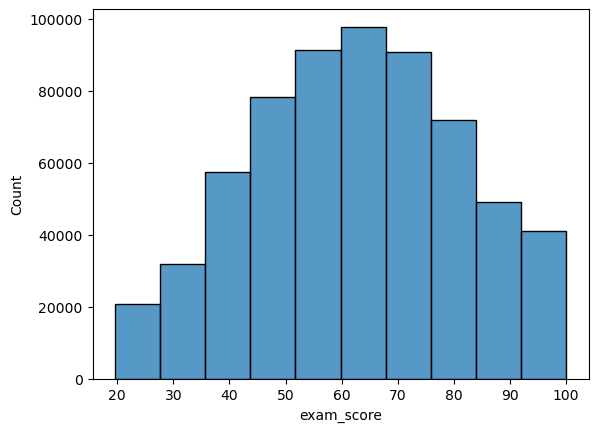

In [99]:
#normality
sns.histplot(data=df1, x="exam_score", bins=10)
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_11560\2199911400.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["exam_score"])


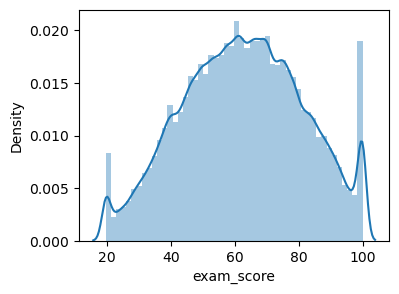

In [15]:
plt.figure(figsize=(4,3))
sns.distplot(df["exam_score"])
plt.show()

In [16]:
from scipy.stats import shapiro
# null - Data is normaly distributed 
# alter - data is not normally distributed 
shapiro(df1["exam_score"])
#in this data is not normally distributed so its supports alter as p value is sooo small , it has 83 zeros after decimal point

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 630000.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9895644677659794), pvalue=np.float64(1.9618170647675346e-84))

In [18]:
from scipy.stats import jarque_bera
# null - Data is normaly distributed 
# alter - data is not normally distributed 
jarque_bera(df1["exam_score"])

SignificanceResult(statistic=np.float64(10301.43010127115), pvalue=np.float64(0.0))

SignificanceResult(statistic=np.float64(82187.43257975184), pvalue=np.float64(0.0))


C:\Users\acer\AppData\Local\Temp\ipykernel_11560\3225497986.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["new_score"])


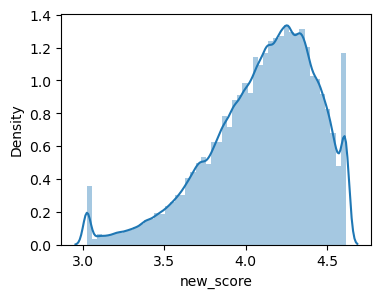

In [19]:
# change to normality # making new column of new score
df1["new_score"]=np.log1p(df1["exam_score"])
print(jarque_bera(df1["new_score"]))
plt.figure(figsize=(4,3))
sns.distplot(df1["new_score"])
plt.show()

#not happening

SignificanceResult(statistic=np.float64(20281.252597277282), pvalue=np.float64(0.0))


C:\Users\acer\AppData\Local\Temp\ipykernel_11560\169661695.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["new_score"])


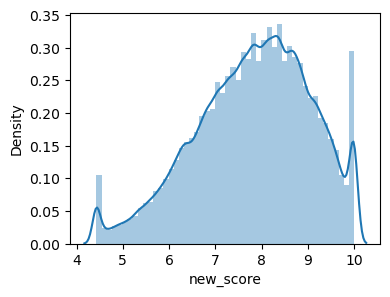

In [20]:
# change to normality
df1["new_score"]=np.sqrt(df1["exam_score"])
print(jarque_bera(df1["new_score"]))
plt.figure(figsize=(4,3))
sns.distplot(df1["new_score"])
plt.show()

#not happening

SignificanceResult(statistic=np.float64(36424.17006553337), pvalue=np.float64(0.0))


C:\Users\acer\AppData\Local\Temp\ipykernel_11560\3151676241.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["new_score"])


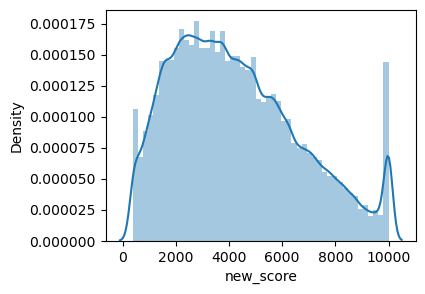

In [21]:
# change to normality
df1["new_score"]=np.square(df1["exam_score"])
print(jarque_bera(df1["new_score"]))
plt.figure(figsize=(4,3))
sns.distplot(df1["new_score"])
plt.show()

#not happening

In [22]:
# Linearity 
df1.corr()["exam_score"].reset_index().sort_values( by=["exam_score"])

,index,exam_score
15,sleep_quality_poor,-0.208717
20,facility_rating_low,-0.171604
19,study_method_self-study,-0.130269
18,study_method_online videos,-0.071656
16,study_method_group study,-0.051422
5,gender_male,-0.012403
9,course_ba,-0.010823
7,course_b.sc,-0.005178
12,course_diploma,-0.001587
8,course_b.tech,0.000353


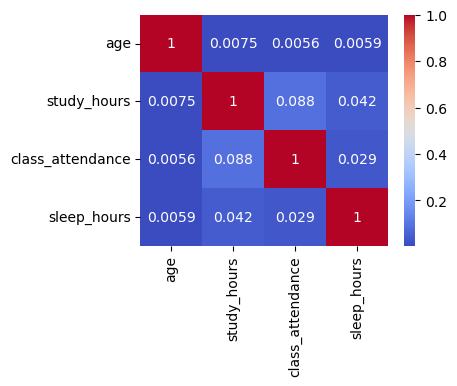

In [23]:
# multicollinearity
cr=df1[['age', 'study_hours', 'class_attendance', 'sleep_hours']].corr()

plt.figure(figsize=(4,3))
sns.heatmap(cr, annot=True, cmap="coolwarm")
plt.show()

### model development

In [28]:
df1.columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score',
       'gender_male', 'gender_other', 'course_b.sc', 'course_b.tech',
       'course_ba', 'course_bba', 'course_bca', 'course_diploma',
       'internet_access_yes', 'sleep_quality_good', 'sleep_quality_poor',
       'study_method_group study', 'study_method_mixed',
       'study_method_online videos', 'study_method_self-study',
       'facility_rating_low', 'facility_rating_medium', 'exam_difficulty_hard',
       'exam_difficulty_moderate'],
      dtype='object')

In [28]:
# features=['age', 'study_hours', 'class_attendance', 'sleep_hours',
#        'gender_male', 'gender_other', 'course_b.sc', 'course_b.tech',
#        'course_ba', 'course_bba', 'course_bca', 'course_diploma',
#        'internet_access_yes', 'sleep_quality_good', 'sleep_quality_poor',
#        'study_method_group study', 'study_method_mixed',
#        'study_method_online videos', 'study_method_self-study',
#        'facility_rating_low', 'facility_rating_medium', 'exam_difficulty_hard',
#        'exam_difficulty_moderate']

In [26]:
df1.drop(columns=["new_score"], inplace=True) 

In [29]:
# seperate y and x
y=df1["exam_score"]
x=df1.drop(columns=["exam_score"])

In [36]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.3, random_state=90)  #.3 is 30% of data as test

In [37]:
model0=LinearRegression()
model0.fit(x_train, y_train)

LinearRegression()

In [38]:
model0.score(x_train, y_train)  # R^2

0.7785217323831057

In [39]:
model0.score(x_test, y_test) # R^2

0.7798603777254705

In [40]:
pd.set_option('display.float_format', '{:.6f}'.format)
np.set_printoptions(suppress=True)

In [41]:
model0.coef_ # m/w

array([-0.01318259,  5.67135611,  0.31268052,  1.32679543, -0.13786924,
        0.17545186, -0.1467503 ,  0.20395523, -0.04085619,  0.22836757,
        0.04013415,  0.24608929,  0.01909491,  4.22712818, -4.66892969,
       -7.21589629, -4.42015598, -8.2623195 , -9.08378993, -7.26332257,
       -3.57945602,  0.0374167 ,  0.00189321])

In [42]:
model0.intercept_ # c

np.float64(17.663932780564494)

In [43]:
#age and score has a negative relationship if age is more then the exam score will be less

In [44]:
x_train.columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma', 'internet_access_yes',
       'sleep_quality_good', 'sleep_quality_poor', 'study_method_group study',
       'study_method_mixed', 'study_method_online videos',
       'study_method_self-study', 'facility_rating_low',
       'facility_rating_medium', 'exam_difficulty_hard',
       'exam_difficulty_moderate'],
      dtype='object')

In [45]:
pd.DataFrame({"col":x_train.columns, "m":model0.coef_}).sort_values(by=["m"], ascending=True)

,col,m
18,study_method_self-study,-9.083790
17,study_method_online videos,-8.262319
19,facility_rating_low,-7.263323
15,study_method_group study,-7.215896
14,sleep_quality_poor,-4.668930
16,study_method_mixed,-4.420156
20,facility_rating_medium,-3.579456
6,course_b.sc,-0.146750
4,gender_male,-0.137869
8,course_ba,-0.040856


In [55]:
pred_train=model0.predict(x_train)

In [58]:
pd.DataFrame({"Act":y_train, "pred":pred_train}).head(10)

,Act,pred
391383,65.400000,53.968053
15701,52.200000,43.446885
245686,70.500000,87.295442
501658,77.300000,69.736302
84509,49.400000,49.690676
621673,80.100000,76.427365
218068,68.700000,75.236634
567513,67.900000,68.138925
24865,64.200000,63.912017
138674,60.100000,66.550886


In [59]:
pred_test=model0.predict(x_test)
pd.DataFrame({"Act":y_test, "pred":pred_test}).head(10)

,Act,pred
232810,44.800000,55.648402
305136,100.000000,99.036786
432287,62.500000,68.595886
519109,69.500000,68.287344
163723,32.700000,48.097854
127226,61.300000,59.400902
144375,63.600000,61.898942
310554,89.400000,77.290291
560742,58.100000,59.936152
333040,61.400000,59.506525


In [57]:
print("MSE: ", metrics.mean_squared_error(y_train, pred_train))
print("RMSE: ",metrics.root_mean_squared_error(y_train, pred_train))
print("MAE: ", metrics.mean_absolute_error(y_train, pred_train))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_train, pred_train))


MSE:  79.22854999044704
RMSE:  8.901042073288219
MAE:  7.107294949591703
MAPE:  0.1315756525033225


In [60]:
print("MSE: ", metrics.mean_squared_error(y_test, pred_test))
print("RMSE: ",metrics.root_mean_squared_error(y_test, pred_test))
print("MAE: ", metrics.mean_absolute_error(y_test, pred_test))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_test))


MSE:  78.83908322278039
RMSE:  8.879137526966254
MAE:  7.086591134074973
MAPE:  0.1314626059449347
